In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

## Simulate data

An example ground truth connectivity matrix `A`

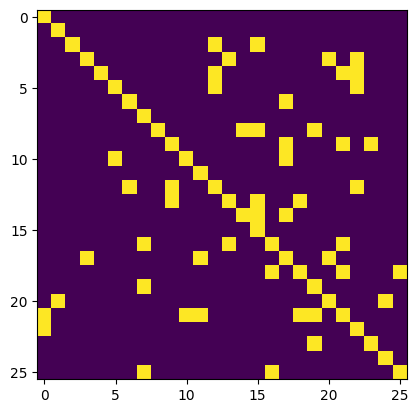

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [3]:
%%time
metrics, N_PASTS, num = [], list(range(1,8)), 1
for a in tqdm(range(num)):
    n_neur, l = 18, 5000   # np.random.randint(25,40,1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1
    
    
    # simulate data
    
    A = adj_mtx(n_neur)
    noise = continuous_noise_fun(num = n_neur, l = l)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0,0.25,A.shape[0]) + noise[:, i]
    X=X.T
    
    print(f'Data {a} of {num} with {X.shape[0]} vars')
    
    # fit algorithm to data
    met = np.zeros((len(N_PASTS), 4))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)
        
        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True)
        gcstar.fit_old(X)
        
        # compute metrics
        gcstar.get_connectivity_matrix()
        gcstar.compute_confusion_matrix(A.T)
        met[k] = gcstar.compute_metrics()
    metrics.append(met)

  0%|          | 0/1 [00:00<?, ?it/s]

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


Data 0 of 1 with 18 vars
1


INFO:src.d_CSL:Step 1/648 (0.15% complete)
INFO:src.d_CSL:Step 1/648 (0.15% complete)
INFO:src.d_CSL:Step 2/648 (0.31% complete)
INFO:src.d_CSL:Step 2/648 (0.31% complete)
INFO:src.d_CSL:Step 3/648 (0.46% complete)
INFO:src.d_CSL:Step 3/648 (0.46% complete)
INFO:src.d_CSL:Step 4/648 (0.62% complete)
INFO:src.d_CSL:Step 4/648 (0.62% complete)
INFO:src.d_CSL:Step 5/648 (0.77% complete)
INFO:src.d_CSL:Step 5/648 (0.77% complete)
INFO:src.d_CSL:Step 6/648 (0.93% complete)
INFO:src.d_CSL:Step 6/648 (0.93% complete)
INFO:src.d_CSL:Step 7/648 (1.08% complete)
INFO:src.d_CSL:Step 7/648 (1.08% complete)
INFO:src.d_CSL:Step 8/648 (1.23% complete)
INFO:src.d_CSL:Step 8/648 (1.23% complete)
INFO:src.d_CSL:Step 9/648 (1.39% complete)
INFO:src.d_CSL:Step 9/648 (1.39% complete)
INFO:src.d_CSL:Step 10/648 (1.54% complete)
INFO:src.d_CSL:Step 10/648 (1.54% complete)
INFO:src.d_CSL:Step 11/648 (1.70% complete)
INFO:src.d_CSL:Step 11/648 (1.70% complete)
INFO:src.d_CSL:Step 12/648 (1.85% complete)
INFO:s

IndexError: index 36 is out of bounds for axis 0 with size 36

In [4]:
for met in metrics:
    print(met)

In [5]:
Metrics = np.zeros((num,7,4))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

0.0

In [6]:
np.mean(Metrics,axis=0)

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

C:\Users\sadiq\AppData\Local\Temp\ipykernel_17040\778157275.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


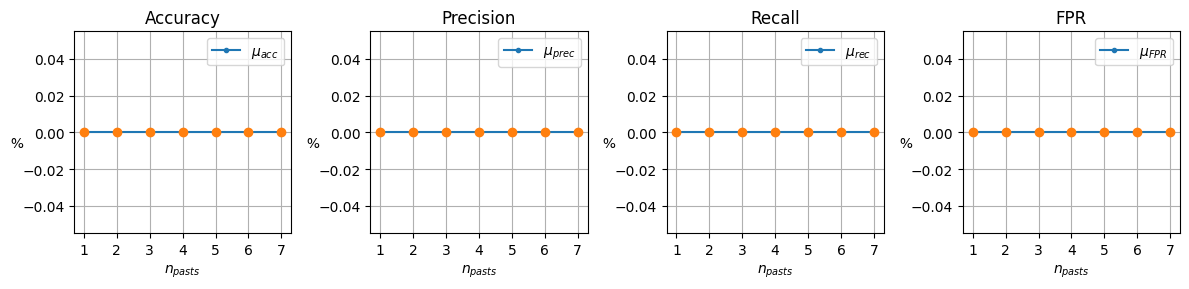

In [7]:
fig,ax=plt.subplots(1,4,figsize=(12,3))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1,1+Metrics.shape[1]), np.mean(Metrics,axis=0)[:,i],marker = '.',label=lab[i])
    ax[i].errorbar(range(1,1+Metrics.shape[1]), np.mean(Metrics,axis=0)[:,i], yerr=np.std(Metrics,axis=0)[:,i],fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]), list(range(1,1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation=180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    ax[i].grid()
    plt.tight_layout()